# Global Coffee Health Dataset


## Contextualização:

O conjunto de dados GlobalCoffeeHealth contém 10.000 registros sintéticos que refletem padrões do mundo real relacionados ao consumo de café, comportamento do sono e condições de saúde em 20 países. Ele inclui informações demográficas, consumo diário de café, níveis de cafeína, duração e qualidade do sono, IMC, frequência cardíaca, estresse, atividade física, problemas de saúde, ocupação, tabagismo e consumo de álcool.

O conjunto de dados representa correlações realistas observadas em pesquisas — como o impacto da cafeína sobre o sono, o estresse e a saúde —, tornando-o adequado para análises estatísticas, modelagem preditiva e estudos relacionados ao estilo de vida e bem-estar.


## Objetivo do projeto:

Uma empresa contratou você para analisar a relação entre o consumo de café e a qualidade do sono, identificando padrões e possíveis fatores associados que possam explicar variações na qualidade do sono dos clientes, por meio de técnicas de análise exploratória e modelagem preditiva.


Link projeto original: https://www.kaggle.com/datasets/uom190346a/global-coffee-health-dataset

### Dicionário de dados:

Este dataset contém informações sobre participantes de uma pesquisa que relaciona consumo de café, hábitos de sono e condições de saúde.


| Coluna | Descrição |
|---------|-----------|
| **ID** | Identificador único de cada registro (1–10000). |
| **Age** | Idade do participante (18 a 80 anos). |
| **Gender** | Gênero: Male, Female ou Other. |
| **Country** | País de residência (20 países representados). |
| **Coffee_Intake** | Consumo diário de café em xícaras (0 a 10). |
| **Caffeine_mg** | Estimativa de cafeína ingerida por dia em mg (1 xícara ≈ 95 mg). |
| **Sleep_Hours** | Média de horas de sono por noite (3 a 10 horas). |
| **Sleep_Quality** | Qualidade do sono: Poor, Fair, Good ou Excellent. |
| **BMI** | Índice de Massa Corporal (15 a 40). |
| **Heart_Rate** | Frequência cardíaca em repouso (50 a 110 bpm). |
| **Stress_Level** | Nível de estresse: Low, Medium ou High. |
| **Physical_Activity_Hours** | Tempo de atividade física semanal em horas (0 a 15). |
| **Health_Issues** | Condições de saúde: None, Mild, Moderate ou Severe. |
| **Occupation** | Ocupação principal: Office, Healthcare, Student, Service, Other. |
| **Smoking** | Fumante: 0 = Não, 1 = Sim. |
| **Alcohol_Consumption** | Consome álcool: 0 = Não, 1 = Sim. |

# Parte 1 

## **Análise Exploratória de Dados (EDA)**

A empresa Health&Life Analytics precisa entender melhor o perfil dos clientes e como o consumo de café se relaciona com aspectos de saúde. Nosso primeiro passo será realizar uma análise exploratória completa, identificando padrões e potenciais problemas nos dados

**1.1. Carregar o dataset.**

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)


# Carregar o conjunto de dados do arquivo CSV
df = pd.read_csv('synthetic_coffee_health_10000(in).csv')
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [3]:
# Verificar dimensões do DataFrame
print(f'Dimensões do DataFrame: {df.shape}')

Dimensões do DataFrame: (10000, 16)


In [4]:
# Verificar informações sobre o DataFrame (colunas, tipos de dados e dados nulos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  str    
 3   Country                  10000 non-null  str    
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  str    
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  str    
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   str    
 13  Occupation               10000 non-null  str    
 14  Smoking                  10000 non

O DataFrame possui 10.000 linhas e 16 colunas. Destas colunas, apenas a variável categórica Health_Issues (condições de saúde) apresenta valores ausentes e, os tipos de dados, são consistentes com suas características. O percentual de valores ausentes será melhor analisado abaixo:


In [5]:
((df.isnull().sum()) / df.shape[0]).mul(100).round(2)

ID                          0.00
Age                         0.00
Gender                      0.00
Country                     0.00
Coffee_Intake               0.00
Caffeine_mg                 0.00
Sleep_Hours                 0.00
Sleep_Quality               0.00
BMI                         0.00
Heart_Rate                  0.00
Stress_Level                0.00
Physical_Activity_Hours     0.00
Health_Issues              59.41
Occupation                  0.00
Smoking                     0.00
Alcohol_Consumption         0.00
dtype: float64

In [6]:
# Verificar valores duplicados no DataFrame
df.duplicated().sum()

np.int64(0)

Constatamos que a variável Health_Issues possui 59,41% dos dados faltantes e o dataset não possui informações duplicadas.

In [7]:
# Verificar estatísticas descritivas para colunas numéricas
df.select_dtypes(include=['number']).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
ID,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,34.95,11.16,18.0,26.00,34.0,43.00,80.0
Coffee_Intake,10000.0,2.51,1.45,0.0,1.50,2.5,3.50,8.2
Caffeine_mg,10000.0,238.41,137.75,0.0,138.75,235.4,332.02,780.3
Sleep_Hours,10000.0,6.64,1.22,3.0,5.80,6.6,7.50,10.0
BMI,10000.0,23.99,3.91,15.0,21.30,24.0,26.60,38.2
Heart_Rate,10000.0,70.62,9.82,50.0,64.00,71.0,77.00,109.0
Physical_Activity_Hours,10000.0,7.49,4.32,0.0,3.70,7.5,11.20,15.0
Smoking,10000.0,0.20,0.40,0.0,0.00,0.0,0.00,1.0
Alcohol_Consumption,10000.0,0.30,0.46,0.0,0.00,0.0,1.00,1.0


In [8]:
# Verificar estatísticas descritivas para colunas de texto
df.describe(include=['str']).T

,count,unique,top,freq
Gender,10000,3,Female,5001
Country,10000,20,Canada,543
Sleep_Quality,10000,4,Good,5637
Stress_Level,10000,3,Low,6989
Health_Issues,4059,3,Mild,3579
Occupation,10000,5,Office,2073


Aparentemente os valores descritivos oscilam em faixas condizentes com as suas características e, a princípio, não necessita passam por tratamento de valores outliers. Ainda, é observado a partir dos dados categóricos que maior parte dos envolvidos na pesquisa é do sexo feminino, residem no Canadá, apresentam boa qualidade de sono, estresse baixo e com problemas de saúde leve.

**1.2. Explorar variáveis numéricas.**

In [9]:
import math
import matplotlib.pyplot as plt
import seaborn as sns


#sns.set_theme(style="whitegrid", palette="deep")
sns.set_theme(style="white")

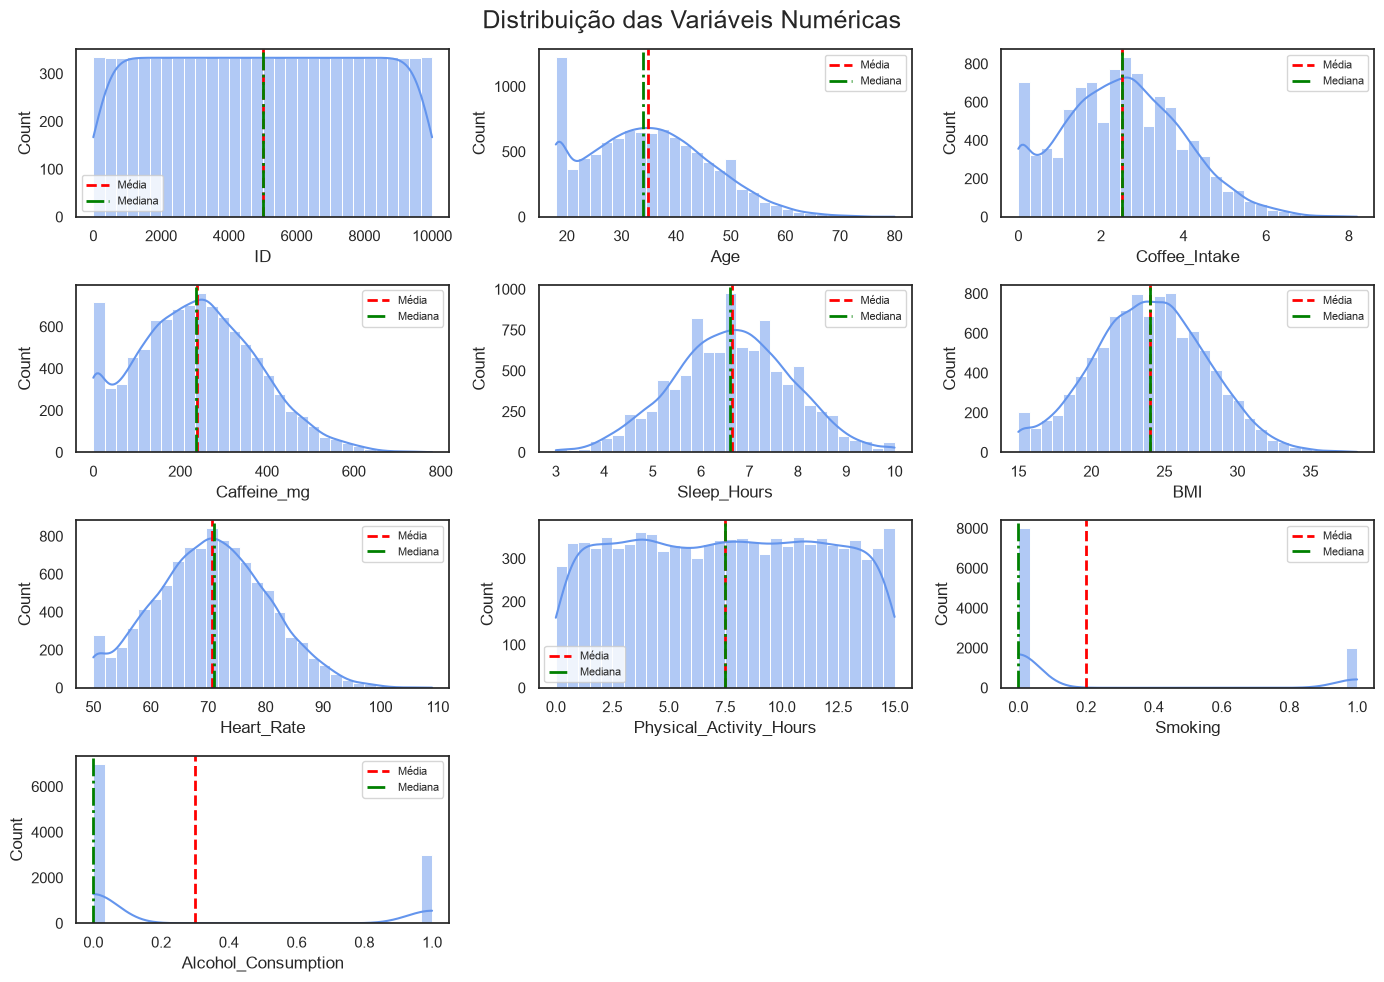

In [10]:
# Seleciona apenas as variáveis numéricas
colunas_numericas = df.select_dtypes(include="number").columns

n = len(colunas_numericas)
ncols = 3
nrows = math.ceil(n / ncols)


fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize=(14, 2.5*nrows))
axes = axes.flatten()

for ax, coluna in zip(axes, colunas_numericas):

    sns.histplot(data=df, x=coluna, kde=True, bins=30,
        color="#6495ED", edgecolor="white", ax=ax)

    media = df[coluna].mean()
    mediana = df[coluna].median()

    ax.axvline(media, color="red", linestyle="--", linewidth=2, label="Média")
    ax.axvline(mediana, color="green", linestyle="-.", linewidth=2, label="Mediana")
    ax.legend(fontsize=8)

# Remove eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

fig.suptitle("Distribuição das Variáveis Numéricas",fontsize=18)

plt.tight_layout()
plt.show()

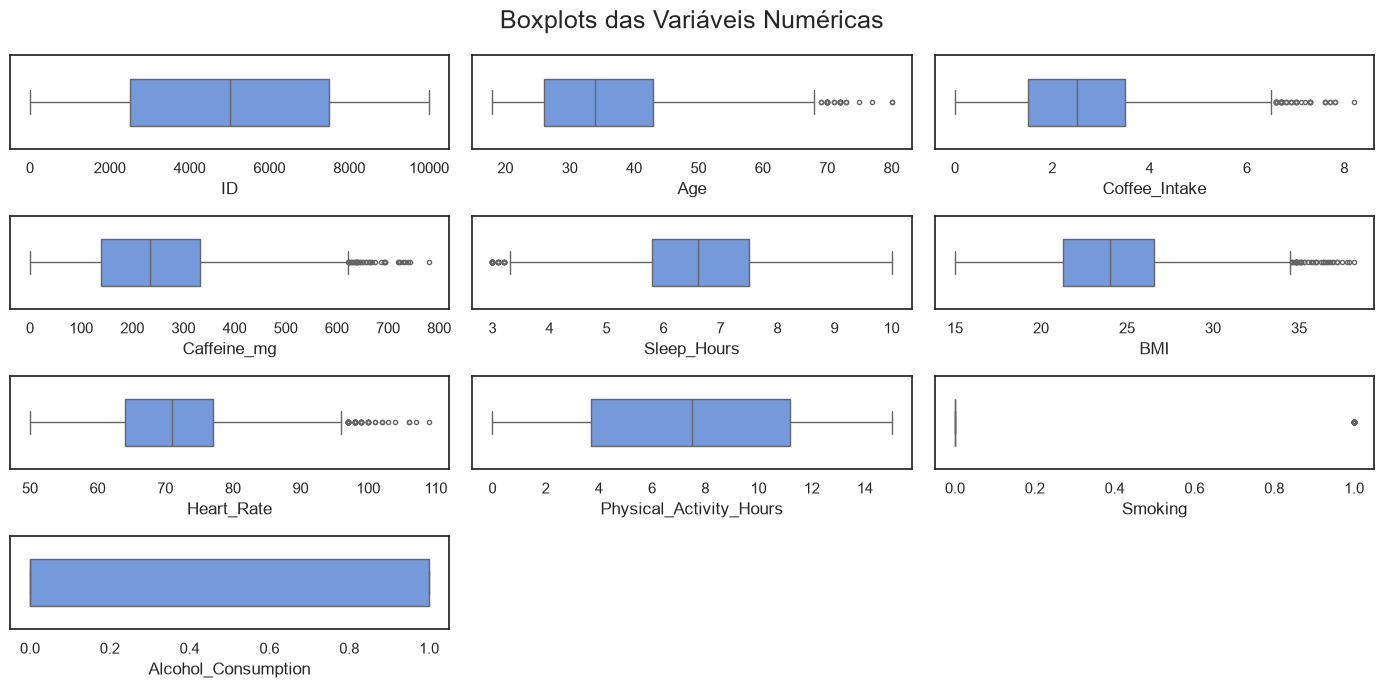

In [11]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 1.75*nrows))
axes = axes.flatten()

for ax, coluna in zip(axes, colunas_numericas):
    sns.boxplot(x=df[coluna], color="#6495ED", width=0.5, fliersize=3, ax=ax)
    ax.set_xlabel(coluna)
    ax.set_ylabel("")

# Remove eixos vazios
for ax in axes[n:]:
    fig.delaxes(ax)

fig.suptitle('Boxplots das Variáveis Numéricas', fontsize=18)

plt.tight_layout()
plt.show()

In [12]:
df[colunas_numericas].skew()

ID                         0.000000
Age                        0.361852
Coffee_Intake              0.263363
Caffeine_mg                0.263181
Sleep_Hours               -0.018317
BMI                        0.047971
Heart_Rate                 0.103866
Physical_Activity_Hours    0.003668
Smoking                    1.497103
Alcohol_Consumption        0.869369
dtype: float64

De acordo com os gráficos acima, observa-se que as variáveias "Age", "Coffee_Intake" e "Caffeine_mg" possuem a média ligeiramente maior do que a mediana, característica de uma assimetria é positiva (confirmada pelo valor de skewness calculado). Isso significa que, para a variável "Coffee_Intake", por exemplo, existem pessoas com elevado consumo de café e isso faz com que a média para esta variável também aumente.

As variáveis "BMI" e "Heart_Rate" apresenta distribuição aproximadamente simétrica, com leve assimetria positiva ocasionada por alguns valores elevados (outliers) na cauda direita. Já a variável "Sleep_Hours", também apresenta simetria aproximadamente normal, porém, com alguns valores pequenos (outliers) na cauda esquerda.

As variáveis "ID" e "Physical_Activity_Hours" apresentam uma distribuição uniforme (ou aproximadamente uniforme), com os seus valores distribuidos de forma aproximadamente homogênea ao longo de todo o intervalo de valores.

"Smoking" e "Alcohol_Consumption" são variáveis binárias.

In [13]:
# Proporção de valores únicos para variáveis categóricas Smoking e Alcohol_Consumption
print(df["Smoking"].value_counts(normalize=True, ascending=False))
print(df["Alcohol_Consumption"].value_counts(normalize=True, ascending=False))

Smoking
0    0.7996
1    0.2004
Name: proportion, dtype: float64
Alcohol_Consumption
0    0.6993
1    0.3007
Name: proportion, dtype: float64


É observado que as variáveis "Smoking" e "Alcohol_Consumption" sao binárias, desbalanceadas e com proporções não muito distante para a distribuição de valores entre as duas variáveis. Foi constatado por meio dos histogramas uma distribuição quase idêntica para as duas variáveis, porém, ao comparar a distribuição das mesmas por meio do gráfico de boxplot observamos algo pouco intuitivo.  

A explicação é que nas bibliotecas geralmente o boxplot é construído a partir dos quartis (Q1, mediana e Q3), e não das médias ou proporções. Trazendo isso para o nosso caso, como a variável "Smoking" apresenta praticamente 80% dos dados iguais a zero, os três quartis caem sobre o valor 0. Já a variável "Alcohol_Consumption" tem 70% dos valores iguais a zero, logo, apenas os quartis 1 e 2 (mediana) são 0, e Q3 é igual a 1. Desta forma, a caixa do boxplot se estende de 0 até 1.

A diferença entre 80% e 70% parecem pequena, mas ela é suficiente para alcançar a posição do terceiro quartil (Q3). É apenas essa mudança no Q3 que faz os gráficos parecerem tão diferentes.

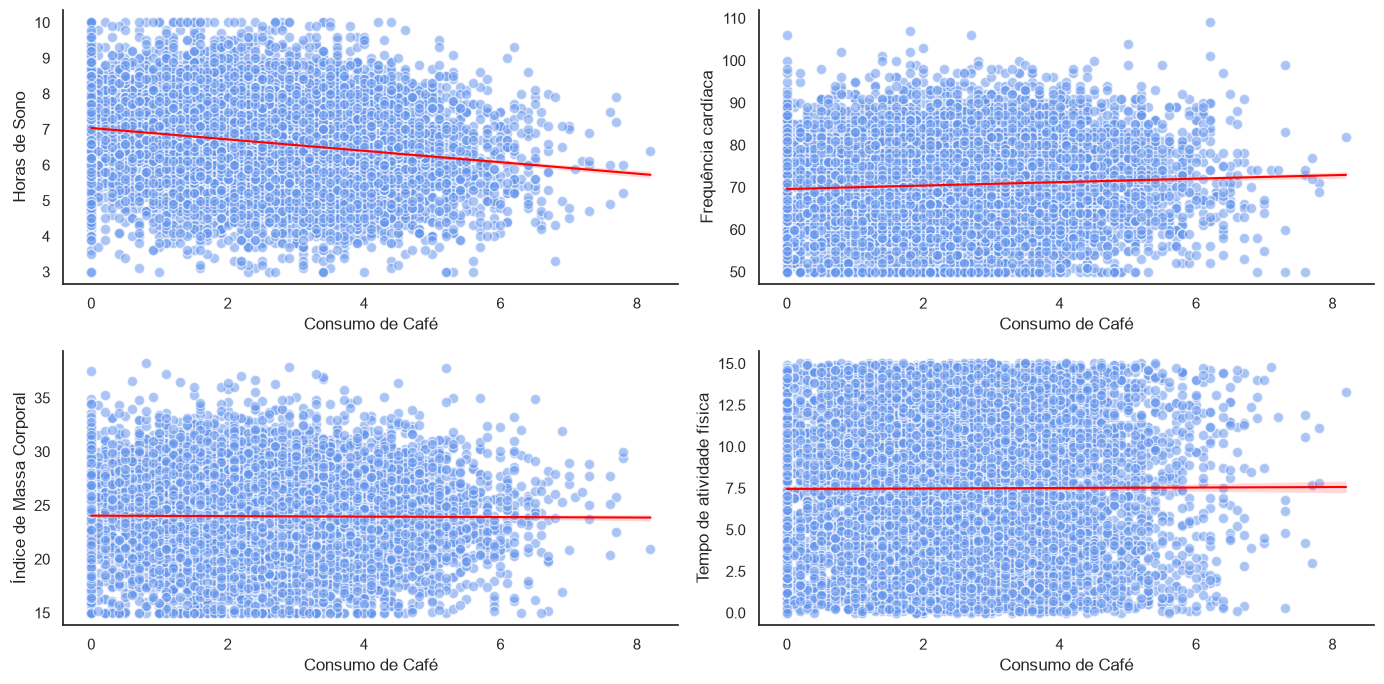

In [14]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(14, 7))
axes = axes.flatten()


# Grafico de dispersão para variável numérica média de horas de sono por noite em relação ao consumo de café
sns.regplot(data = df, x = 'Coffee_Intake', y = 'Sleep_Hours',
            scatter_kws={"s": 55, "alpha": 0.55, "color": "#6495ED", "edgecolor": "white"},
            line_kws={"color": "red", "linewidth": 1.5},
            ax=axes[0])
sns.despine(ax=axes[0])
axes[0].set_xlabel("Consumo de Café")
axes[0].set_ylabel("Horas de Sono")



# Grafico de dispersão para variável numérica frequência cardíaca em repouso em relação ao consumo de café
sns.regplot(data = df, x = 'Coffee_Intake', y = 'Heart_Rate',
            scatter_kws={"s": 55, "alpha": 0.55, "color": "#6495ED", "edgecolor": "white"},
            line_kws={"color": "red", "linewidth": 1.5},
            ax=axes[1])
sns.despine(ax=axes[1])
axes[1].set_xlabel("Consumo de Café")
axes[1].set_ylabel("Frequência cardíaca")



# Grafico de dispersão para variável numérica índice de massa corporal em relação ao consumo de café
sns.regplot(data = df, x = 'Coffee_Intake', y = 'BMI',
            scatter_kws={"s": 55, "alpha": 0.55, "color": "#6495ED", "edgecolor": "white"},
            line_kws={"color": "red", "linewidth": 1.5},
            ax=axes[2])
sns.despine(ax=axes[2])
axes[2].set_xlabel("Consumo de Café")
axes[2].set_ylabel("Índice de Massa Corporal")



# Grafico de dispersão para variável numérica pressão arterial em relação ao consumo de café
sns.regplot(data = df, x = 'Coffee_Intake', y = 'Physical_Activity_Hours',
            scatter_kws={"s": 55, "alpha": 0.55, "color": "#6495ED", "edgecolor": "white"},
            line_kws={"color": "red", "linewidth": 1.5},
            ax=axes[3])
sns.despine(ax=axes[3])
axes[3].set_xlabel("Consumo de Café")
axes[3].set_ylabel("Tempo de atividade física")

plt.tight_layout()
plt.show()

O Scatterplots acima mostra a relação entre algumas variáveis numéricas com o consumo diário de café. A partir do primeiro gráfico (superior esquerdo), verifica-se que à medida que o consumo de café aumenta a quantidade de horas de sono tende a diminuir. Análise similar é feito entre o consumo de café e a frequência cardíaca do pesquisado, porém, observou um pequeno aumento na frequência cardíaca a medida que o consumo de café aumentou.

Já as linhas de tendência entre o consumo de café e as variáveis Índice de massa corporal (BMI) e Tempo de atividade física por semana (Physical_Activity_Hours) permaneceram na praticamente na horizontal, indicando ausência de relação linear entre essas variáveis (isto é, o consumo de café não afeta IMC e nem o tempo de atividade praticado). 

**1.3. Explorar variáveis categóricas.**

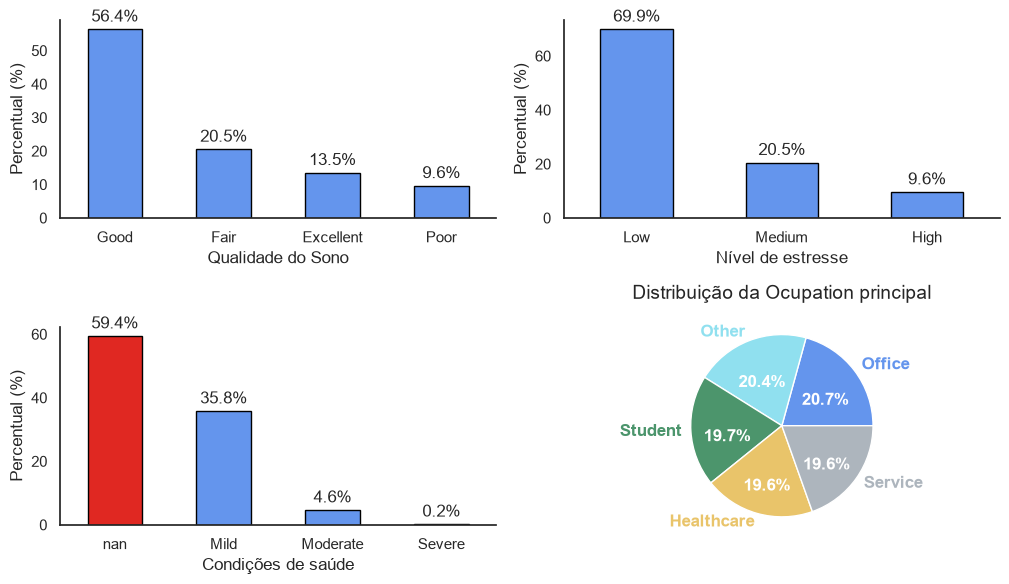

In [15]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 6))
axes = axes.flatten()



# Verificar a frequência relativa por categoria de Sleep_Quality
df['Sleep_Quality'].value_counts(normalize=True, ascending=False).mul(100).plot(kind="bar",edgecolor="black", color="#6495ED",ax=axes[0])
axes[0].set_xlabel("Qualidade do Sono")
axes[0].set_ylabel("Percentual (%)")
sns.despine(ax=axes[0])
# Adiciona os valores sobre as barras
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3)



# Verificar a frequência relativa por categoria de Stress_Level
df['Stress_Level'].value_counts(normalize=True, ascending=False).mul(100).plot(kind="bar",edgecolor="black", color="#6495ED",ax=axes[1])
axes[1].set_xlabel("Nível de estresse")
axes[1].set_ylabel("Percentual (%)")
sns.despine(ax=axes[1])
# Adiciona os valores sobre as barras
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", padding=3)


# Verificar a frequência relativa por categoria de Health_Issues
cores = ["#E02822"] + ['#6495ED'] * 3
df['Health_Issues'].value_counts(normalize=True, ascending=False, 
dropna=False).mul(100).plot(kind="bar",edgecolor="black",color=cores,ax=axes[2])
axes[2].set_xlabel("Condições de saúde")
axes[2].set_ylabel("Percentual (%)")
sns.despine(ax=axes[2])
# Adiciona os valores sobre as barras
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.1f%%", padding=3)



# Verificar a frequência relativa por categoria de Occupation
ocupation = df['Occupation'].value_counts(normalize=True, ascending=False).mul(100).to_frame()
cores = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a', '#adb5bd' ]
ptc, text, autotexts = axes[3].pie(data = ocupation,
                          x = "proportion", labels = ocupation.index, autopct="%.1f%%",
                          pctdistance=0.6, textprops={"size": 12, "fontweight":"bold", "color": '#FFFFFF'},
                          colors = cores, radius=1.15)
axes[3].set_title('Distribuição da Ocupation principal',fontsize=14, pad=20)
# Move todos os percentuais 
for t in autotexts:
    x, y = t.get_position()
    t.set_position((x, y - 0.1))
# Move o gráfico 
pos = axes[3].get_position()
axes[3].set_position([pos.x0 + 0.2, pos.y0, pos.width, pos.height])
# Ajustando as cores das regiões relativas as fatias
for i, p in enumerate(ptc):
  text[i].set_color(p.get_facecolor())



# Rotação dos rótulos do eixo X
for ax in axes:
    ax.tick_params(axis="x", rotation=0)


plt.tight_layout()
plt.show()

A variável Qualidade do sono e Nível de estresse possuem categorias desbalanceadas. O primeira gráfico mostra que a qualidade de sono boa foi a classe predominante, com 56,4% e, no segundo gráfico, o nível de estresse baixo teve maior ocorrência (em 69,9% dos pesquisados). As demais classes de ambos os gráficos tiveram reduções.


Assim, como as variáveis Qualidade do sono e Nível de estresse são desbalanceadas, Condições de saúde também é. Porém, para condições de saúde, quase 60% dos pesquisados optaram por não colocar ou tiveram perdas de informações. A Ocupação principal apresenta classes com quantidade de participantes aproximadas entre elas, como pode ser visto no gráfico de pizza.

In [16]:
# Frequência relativa das categorias de "Gender"
print(df['Gender'].value_counts(normalize=True, ascending=False).mul(100), '\n')

# Frequência relativa das categorias de "Country"
print(df['Country'].value_counts(normalize=True, ascending=False).mul(100))


Gender
Female    50.01
Male      47.73
Other      2.26
Name: proportion, dtype: float64 

Country
Canada         5.43
India          5.24
Norway         5.23
China          5.21
UK             5.19
Sweden         5.13
South Korea    5.12
Finland        5.10
Italy          5.09
Switzerland    5.00
France         4.99
Germany        4.97
Belgium        4.97
Australia      4.97
Netherlands    4.94
Spain          4.86
Mexico         4.83
Japan          4.69
Brazil         4.56
USA            4.48
Name: proportion, dtype: float64


In [17]:
country_cv = (df['Country'].value_counts(normalize=True, ascending=False).mul(100).std()) / (df['Country'].value_counts(normalize=True, ascending=False).mul(100).mean())
print(country_cv.round(4), '%')

0.0468 %


A variável Gender tem as categorias Feminina e Masculina aproximadamente equilibradas e a classe Outros com apenas 2,26% dos participantes. A variável País (country) apresenta dados mais equilibrados, com a quantidade de participantes na pesquisa variando de 4,48% até 5,43%, com um coeficiente de variação baixo (cv igual a 0,0468%).


**4. Investigar correlações.**

Como as variáveis Sleep_Quality e Stress_Level apresentam uma certa ordem entre as suas categorias, irei fazer um mapeamento e incluí-las na análise de correlação que será feita a seguir.

In [18]:
# Variáveis categoricas ordinais:
var_cat_ordinais = [
    'Sleep_Quality',
    'Stress_Level'
]

# Verificar valores unicos para variáveis Sleep_Quality e Stress_Level
for var in var_cat_ordinais:
  print('\n', var, '\n')

  print('Qtd de valores unicos:', df[var].nunique())
  print('Valores unicos:', df[var].unique().tolist())

  print('='*50)



 Sleep_Quality 

Qtd de valores unicos: 4
Valores unicos: ['Good', 'Fair', 'Excellent', 'Poor']

 Stress_Level 

Qtd de valores unicos: 3
Valores unicos: ['Low', 'Medium', 'High']


In [19]:
# Dicionário para mapear as categorias ordinais de qualidade do sono para valores numéricos
dict_sleep_quality = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent':3
}
sleep_quality_numeric = df['Sleep_Quality'].map(dict_sleep_quality).rename("sleep_quality_numeric")



# Dicionário para mapear as categorias ordinais de nivel de estresse para valores numéricos
dict_stress_level  = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
stress_level_numeric = df['Stress_Level'].map(dict_stress_level).rename("stress_level_numeric")



# Criar DataFrame com as variáveis numéricas para realizar a análise de correlação
df_features = pd.concat([df, sleep_quality_numeric,stress_level_numeric], axis=1)

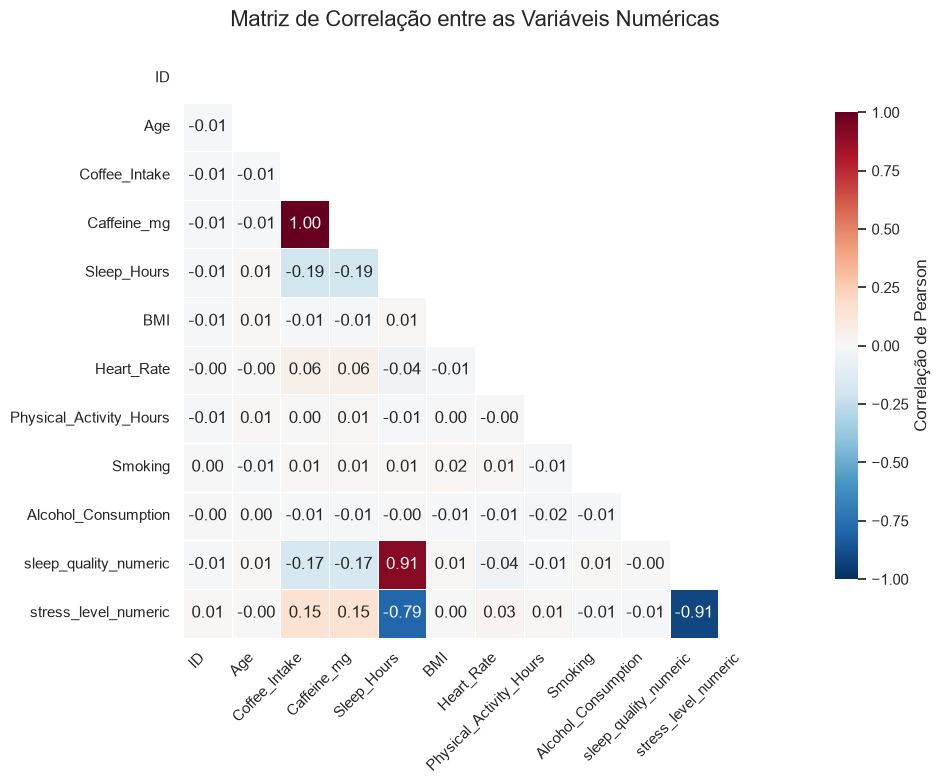

In [20]:
import numpy as np

# Calcular a matriz de correlação entre as variáveis numéricas
correlacao = df_features.corr(numeric_only=True).round(2)

# Máscara para ocultar o triângulo superior
mask = np.triu(np.ones_like(correlacao, dtype=bool))


# Criar grafico de calor (heatmap) da matriz de correlação
plt.figure(figsize=(14, 8))
sns.heatmap(correlacao, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlação de Pearson"}
)

plt.title("Matriz de Correlação entre as Variáveis Numéricas", fontsize=16, pad=20)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

A análise de correlação permite medir a intensidade e a direção da relação entre duas variáveis. Ela ajuda a identificar se as variáveis tendem a aumentar ou diminuir juntas, mas não estabelece uma relação de causa e efeito.


Acima é observado uma correlação perfeita, entre "Coffee_Intake" e "Caffeine_mg". Outra combinação com relação impactante é a qualidade do sono que tem correlação forte positiva com a quantidade de horas dormidas (r = 0,91).


Agora, com correlação negativa forte, temos a qualidade do sono com o nível de estresse (r = - 0,91), indicando que quanto melhor a qualidade do sono menor será o nível de estresse. Ainda por essa ótica, a quantidade média de horas dormidas é inversamente proporcional ao nível de estresse (r = - 0,71), isto é, quanto mais horas a pessoa dorme menor tende a ser o estresse.   


Pouco correlacionadas positivamente é a quantidade de xícaras de café consumida (ou cafeína ingerida em miligramas) com o nível de estresse (r = 0.15). Além disso, as variáveis Coffee_Intake e Caffeine_mg também tem relação positiva baixa com a frequência cardíaca em repouso (r = 0,06). Ademais, a média de horas de sono diminui à medida que a quantidade de café consumida é maior, tendo relação negativa (r = - 0,19).

# Parte 2

## **Visualização e Insights**

Após entender a estrutura dos dados, precisamos gerar visualizações e análises comparativas que tragam valor para o negócio. O objetivo é comunicar de forma clara como o café, o estresse e outros fatores impactam o sono.

**2.1 - Gráficos comparativos para relacionar variáveis do conjunto de dados.**

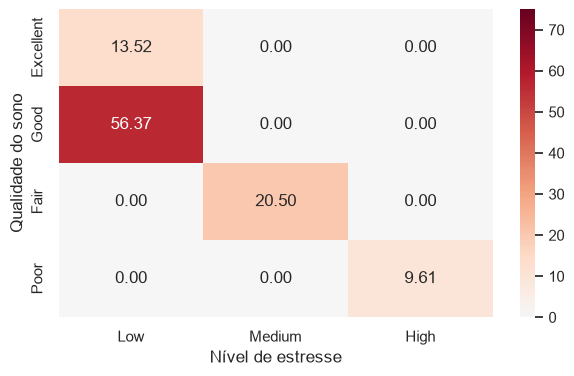

In [21]:
# Tabela da distribuição percentual conjunta entre qualidade do sono e nível de estresse
tab_sleep_stresse = (pd.crosstab(df_features['Sleep_Quality'], df_features['Stress_Level'], 
                                   normalize= True).mul(100)
                                   .reindex(index = ['Excellent','Good','Fair','Poor'])
                                   .reindex(columns = ['Low', 'Medium', 'High']) 
                                   )


# Mapa de calor da distribuição percentual conjunta entre qualidade do sono e nível de estresse
plt.subplots(figsize=(7,4))

sns.heatmap(tab_sleep_stresse, 
            cmap="RdBu_r", center=0, vmin= 0, vmax=75, annot=True, fmt=".2f")
plt.xlabel('Nível de estresse')
plt.ylabel('Qualidade do sono')
plt.show()

A partir da tabela de contingência normalizada entre a Qualidade do sono e o Nível de estresse, observa-se que pessoas que têm o nível de estresse baixo podem ter associação com uma qualidade de sono boa (Good) ou excelente (Excellent). Por outro lado, participantes que descreveram um nível de estresse médio relatam que a qualidade do sono é Fair. Ainda, pessoas que queixaram de um nível de estresse mais elevado tem um sono ruim (Poor). 

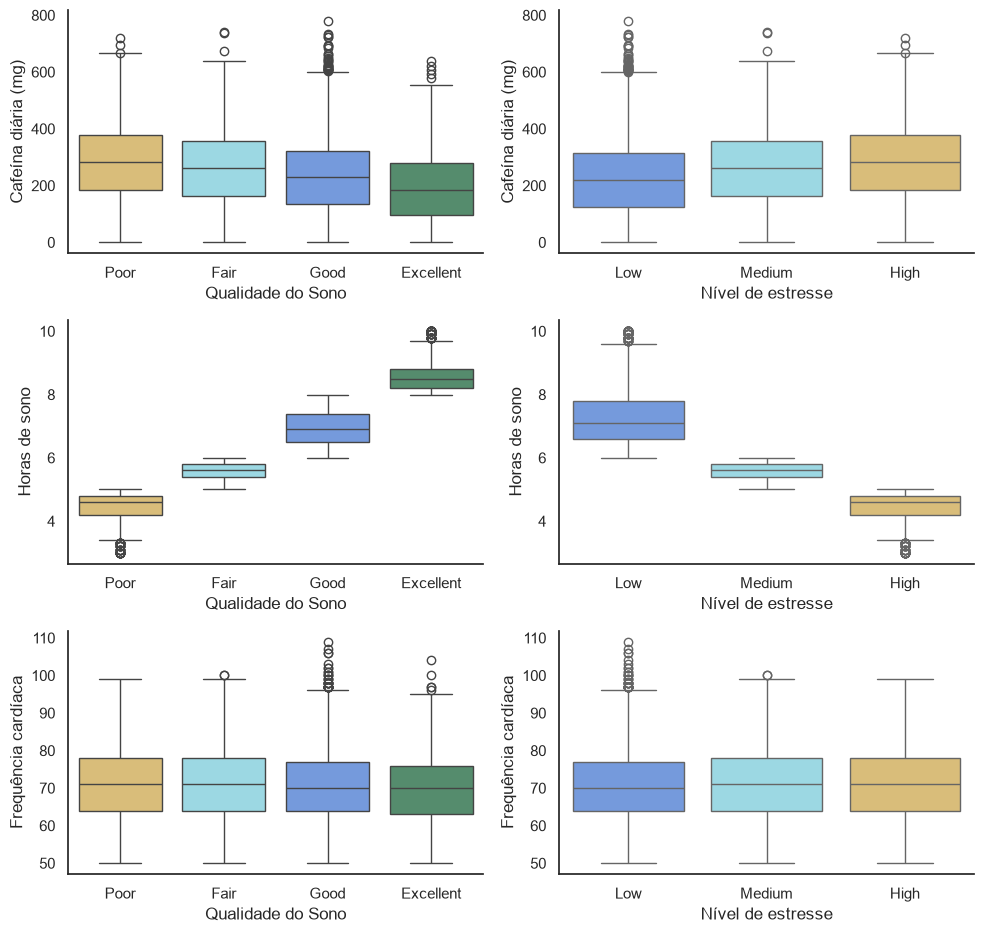

In [22]:
fig, axes = plt.subplots(3,2, figsize=(10,9.5))
axes = axes.flatten()


# Boxplot para Caffeine_mg segmentada por Sleep_Quality
cores_1 = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a']
sns.boxplot(data=df_features, x='Sleep_Quality', y='Caffeine_mg', hue='Sleep_Quality',palette=cores_1, 
            order= ['Poor', 'Fair', 'Good', 'Excellent'], ax= axes[0])
axes[0].set_xlabel('Qualidade do Sono')
axes[0].set_ylabel('Cafeína diária (mg)')
sns.despine(ax = axes[0])



# Boxplot para Caffeine_mg segmentada por Stress_Level
cores_2 = ['#6495ED', '#90e0ef', '#e9c46a']
sns.boxplot(data=df_features, x='Stress_Level', y='Caffeine_mg', hue='Stress_Level', palette=cores_2, 
            order= ['Low', 'Medium', 'High'], ax= axes[1])
axes[1].set_xlabel('Nível de estresse')
axes[1].set_ylabel('Cafeína diária (mg)')
sns.despine(ax = axes[1])



# Boxplot para Sleep_Hours segmentada por Sleep_Quality
cores_1 = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a']
sns.boxplot(data=df_features, x='Sleep_Quality', y='Sleep_Hours', hue='Sleep_Quality', palette=cores_1, 
            order= ['Poor', 'Fair', 'Good', 'Excellent'], ax= axes[2])
axes[2].set_xlabel('Qualidade do Sono')
axes[2].set_ylabel('Horas de sono')
sns.despine(ax = axes[2])



# Boxplot para Sleep_Hours segmentada por Stress_Level
cores_2 = ['#6495ED', '#90e0ef', '#e9c46a']
sns.boxplot(data=df_features, x='Stress_Level', y='Sleep_Hours', hue='Stress_Level', palette=cores_2, 
            order= ['Low', 'Medium', 'High'], ax= axes[3])
axes[3].set_xlabel('Nível de estresse')
axes[3].set_ylabel('Horas de sono')
sns.despine(ax = axes[3])



# Boxplot para Heart_Rate segmentada por Sleep_Quality
cores_1 = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a']
sns.boxplot(data=df_features, x='Sleep_Quality', y='Heart_Rate', hue='Sleep_Quality', palette=cores_1, 
            order= ['Poor', 'Fair', 'Good', 'Excellent'], ax= axes[4])
axes[4].set_xlabel('Qualidade do Sono')
axes[4].set_ylabel('Frequência cardíaca')
sns.despine(ax = axes[4])



# Boxplot para Heart_Rate segmentada por Stress_Level
cores_2 = ['#6495ED', '#90e0ef', '#e9c46a']
sns.boxplot(data=df_features, x='Stress_Level', y='Heart_Rate', hue='Stress_Level', palette=cores_2, 
            order= ['Low', 'Medium', 'High'], ax= axes[5])
axes[5].set_xlabel('Nível de estresse')
axes[5].set_ylabel('Frequência cardíaca')
sns.despine(ax = axes[5])


plt.tight_layout()
plt.show()

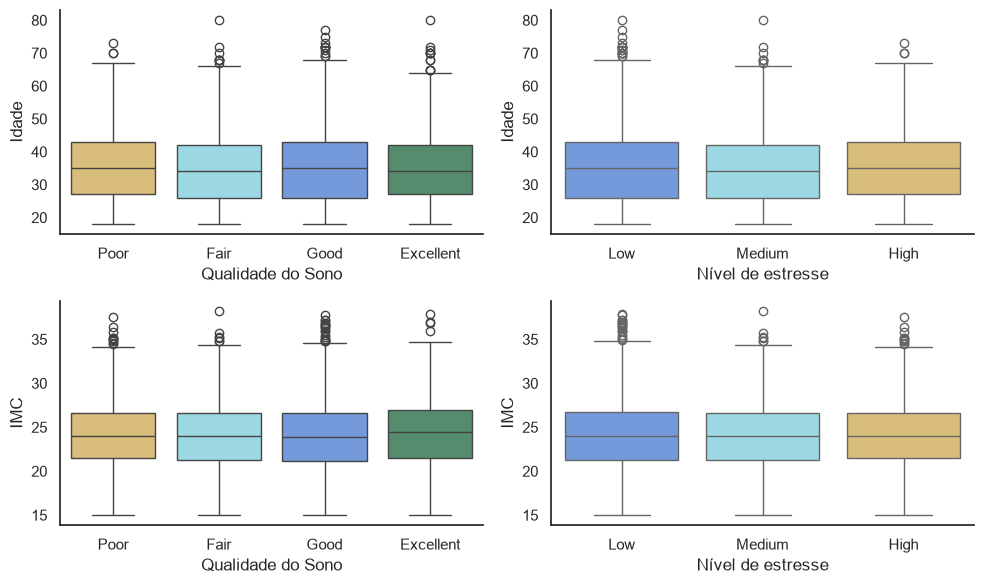

In [23]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()


# Boxplot para Age segmentada por Sleep_Quality
cores_1 = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a']
sns.boxplot(data=df_features, x='Sleep_Quality', y='Age', hue='Sleep_Quality',palette=cores_1, 
            order= ['Poor', 'Fair', 'Good', 'Excellent'], ax= axes[0])
axes[0].set_xlabel('Qualidade do Sono')
axes[0].set_ylabel('Idade')
sns.despine(ax = axes[0])



# Boxplot para Age segmentada por Stress_Level
cores_2 = ['#6495ED', '#90e0ef', '#e9c46a']
sns.boxplot(data=df_features, x='Stress_Level', y='Age', hue='Stress_Level', palette=cores_2, 
            order= ['Low', 'Medium', 'High'], ax= axes[1])
axes[1].set_xlabel('Nível de estresse')
axes[1].set_ylabel('Idade')
sns.despine(ax = axes[1])



# Boxplot para BMI segmentada por Sleep_Quality
cores_1 = ['#6495ED', '#90e0ef', '#4c956c', '#e9c46a']
sns.boxplot(data=df_features, x='Sleep_Quality', y='BMI', hue='Sleep_Quality',palette=cores_1, 
            order= ['Poor', 'Fair', 'Good', 'Excellent'], ax= axes[2])
axes[2].set_xlabel('Qualidade do Sono')
axes[2].set_ylabel('IMC')
sns.despine(ax = axes[2])



# Boxplot para BMI segmentada por Stress_Level
cores_2 = ['#6495ED', '#90e0ef', '#e9c46a']
sns.boxplot(data=df_features, x='Stress_Level', y='BMI', hue='Stress_Level', palette=cores_2, 
            order= ['Low', 'Medium', 'High'], ax= axes[3])
axes[3].set_xlabel('Nível de estresse')
axes[3].set_ylabel('IMC')
sns.despine(ax = axes[3])



plt.tight_layout()
plt.show()

Com base nos boxplots apresentados acima, pode-se fazer algumas observações: 

- Uma qualidade de sono ruim pode estar associada a um maior consumo de cafeína por dia.
- Pessoas com baixo nível de estresse consomem níveis menos cafeína, enquanto, pessoas com níveis de estresse mais elevado consomem mais cafeína diariamente.
- Pessoas com uma qualidade de sono boa e excelente podem ter a frequência cardíaca mais baixa. O mesmo é válido para pessoas com um nível de estresse menor. Observação: exceto para alguns "outliers".
- Pessoas com qualidade de sono excelente tiveram níveis de idade menores entre os bigodes do boxplot, embora, pessoas com nível de estresse médio e alto também têm níveis de idade mais baixos.

**2.2 - Análises segmentadas por grupos:**

Abaixo, vamos analisar se existe diferenças de sono por gênero.

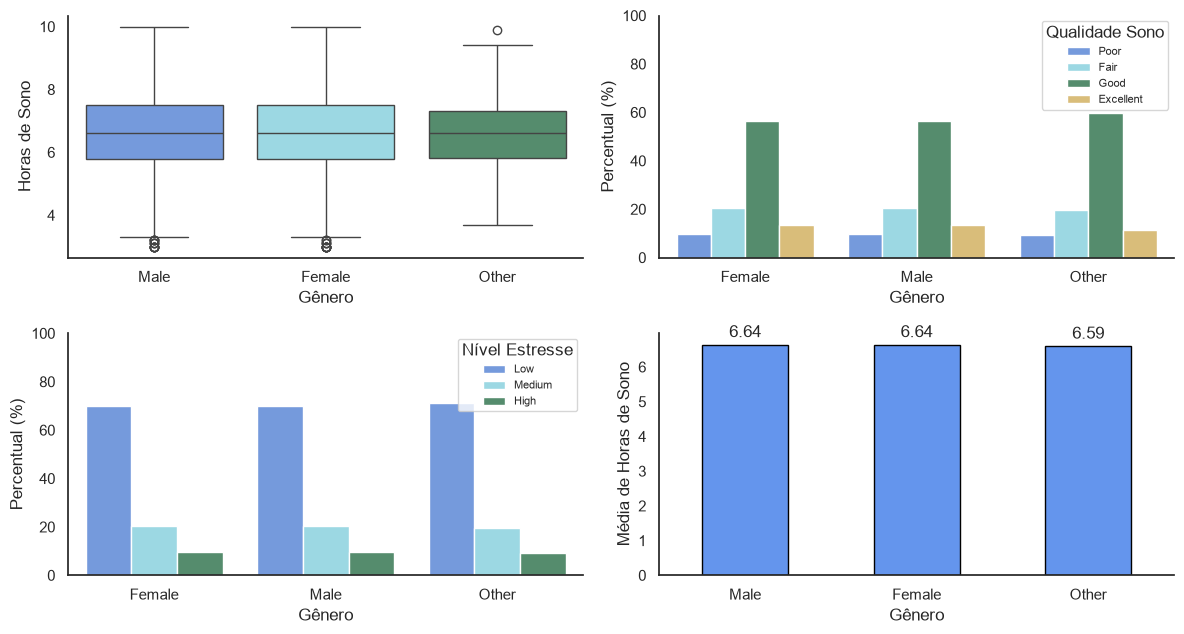

Resumo de Horas de Sono por Gênero:
         count  mean   std  min   25%  50%  75%   max
Gender                                               
Female  5001.0  6.64  1.22  3.0  5.80  6.6  7.5  10.0
Male    4773.0  6.64  1.22  3.0  5.80  6.6  7.5  10.0
Other    226.0  6.59  1.19  3.7  5.82  6.6  7.3   9.9


In [24]:
fig, axes = plt.subplots(2, 2, figsize = (12,6.5))
axes = axes.flatten()



# Boxplot: Sleep_Hours por Gender
sns.boxplot(data=df_features, x='Gender', y='Sleep_Hours',    
            hue='Gender', palette=cores_1[:3], legend=False, ax=axes[0])
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Horas de Sono')
#axes[0].set_title('Distribuição de Horas de Sono por Gênero')
sns.despine(ax=axes[0])



# # Calcular percentual de cada qualidade do sono dentro de cada gênero
df_quality_pct = (df_features.groupby(['Gender', 'Sleep_Quality']).size().reset_index(name='Quantidade'))

df_quality_pct['Percentual'] = (
    df_quality_pct['Quantidade'] / df_quality_pct.groupby('Gender')['Quantidade'].transform('sum') * 100
)
# Boxplot: Sleep_Quality por Gender
sleep_quality_order = ['Poor', 'Fair', 'Good', 'Excellent']
sns.barplot(data=df_quality_pct, x='Gender', y='Percentual', hue='Sleep_Quality',
    hue_order=sleep_quality_order, palette=cores_1, ax=axes[1])
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Percentual (%)')
axes[1].set_ylim(0, 100)
axes[1].legend(title='Qualidade Sono', fontsize=8)
sns.despine(ax=axes[1])



# # Calcular percentual de cada nível de estresse dentro de cada gênero
df_stress_pct = (df_features.groupby(['Gender', 'Stress_Level']).size().reset_index(name='Quantidade'))

df_stress_pct['Percentual'] = (
    df_stress_pct['Quantidade'] / df_stress_pct.groupby('Gender')['Quantidade'].transform('sum') * 100
)
# Boxplot: Stress_Level por Gender
stress_order = ['Low', 'Medium', 'High']
sns.barplot(data=df_stress_pct, x='Gender', y='Percentual', hue='Stress_Level',
    hue_order=stress_order, palette=cores_1[:3], ax=axes[2])
axes[2].set_xlabel('Gênero')
axes[2].set_ylabel('Percentual (%)')
axes[2].set_ylim(0, 100)
axes[2].legend(title='Nível Estresse', fontsize=8)
sns.despine(ax=axes[2])



# Média de Horas de Sono por gênero
media_sono_genero = df_features.groupby('Gender')['Sleep_Hours'].mean().sort_values(ascending=False)
media_sono_genero.plot(kind='bar', edgecolor='black', color='#6495ED', ax=axes[3])
axes[3].set_xlabel('Gênero')
axes[3].set_ylabel('Média de Horas de Sono')
#axes[3].set_title('Média de Horas de Sono por Gênero')
axes[3].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[3])

for container in axes[3].containers:
    axes[3].bar_label(container, fmt='{:.2f}', padding=3)

plt.tight_layout()
plt.show()

# Resumo estatístico
print("Resumo de Horas de Sono por Gênero:")
print(df_features.groupby('Gender')['Sleep_Hours'].describe().round(2))

A análise por gênero indica que as horas médias de sono são bastante semelhantes entre os grupos, com aproximadamente 6,6 horas para Male, Female e Other. Em relação à qualidade do sono, a categoria Good apresenta predominância em todos os gêneros, seguida por Fair e Excellent. Quanto ao nível de estresse, observa-se também predominância da classificação Low, seguida por Medium e High. De modo geral, não foram observadas diferenças expressivas para o gênero nos padrões de sono e estresse.

A seguir será verificaro comportamento entre Idade e Estresse em conjunto com Consumo de café.

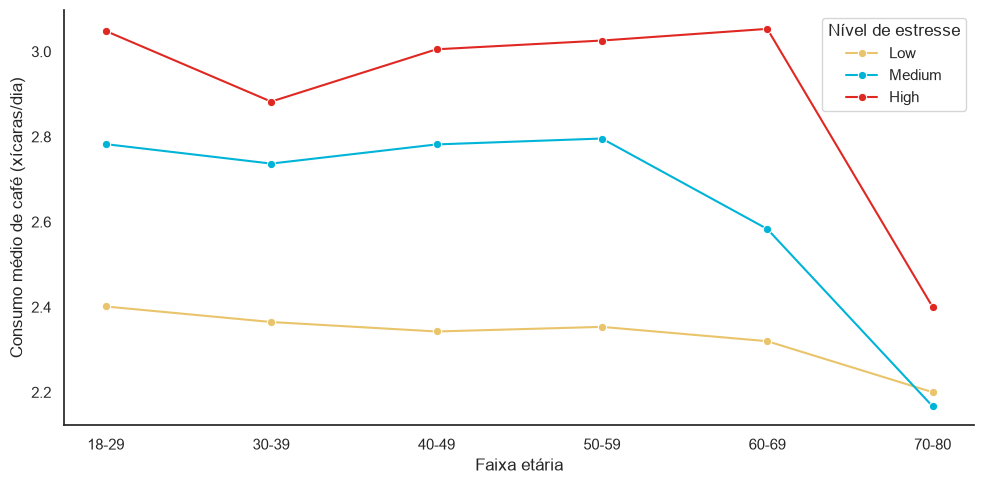

In [25]:
# Calcular a média de consumo de café por faixa etária e nível de estresse
age_bins = [18, 30, 40, 50, 60, 70, 81]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70-80']

df_age_stress = df_features[['Age', 'Stress_Level', 'Coffee_Intake']].copy()
df_age_stress['Age_Group'] = pd.cut(df_age_stress['Age'], bins=age_bins, labels=age_labels, right=False)

tab_age_coffee = (df_age_stress.groupby(['Age_Group', 'Stress_Level'],observed=True)['Coffee_Intake'].mean().reset_index())


# Grafico de linha para mostrar a média de consumo de café por faixa etária e nível de estresse
fig, ax = plt.subplots(figsize=(10, 5))

stress_order = ['Low', 'Medium', 'High']
sns.lineplot(data=tab_age_coffee, x='Age_Group', y='Coffee_Intake', hue='Stress_Level',    
             hue_order=stress_order, palette=['#e9c46a', '#00b4d8', '#E02822'], marker='o', ax=ax)

ax.set_xlabel('Faixa etária')
ax.set_ylabel('Consumo médio de café (xícaras/dia)')
ax.legend(title='Nível de estresse')
sns.despine()

plt.tight_layout()
plt.show()

Observa-se uma associação entre o nível de estresse e o consumo médio de café, com maiores níveis de estresse apresentando, em geral, maior consumo de café. Essa diferença é mais evidente nas faixas etárias de 18 a 69 anos, nas quais o grupo High mantém consumo próximo a 3 xícaras por dia, enquanto os grupos Medium e Low apresentam médias inferiores. A partir dos 60 anos, observa-se uma redução mais acentuada no consumo, especialmente entre os níveis Medium e High. Na faixa de 70–80 anos, as médias se aproximam, indicando um comportamento distinto das demais faixas etárias. De modo geral, os resultados sugerem que o nível de estresse apresenta maior diferenciação no consumo de café do que a idade, embora análises estatísticas adicionais sejam necessárias para verificar a significância dessas diferenças.

**2.3 - Identifique padrões e escreva insights de negócio:**

“Clientes com alto consumo de cafeína dormem em média X horas a menos.”\
“O nível de estresse X altera [...] a qualidade do sono.”

A seguir, será verificado se clientes com alto consumo de cafeína apresentam, em média, menor quantidade de horas de sono.

In [26]:
cafeina_mg_class = []

for i in range(0, len(df_features['Caffeine_mg'])):
    if df_features['Caffeine_mg'][i] > 400:
        cafeina_mg_class.append('Alto')
    elif df_features['Caffeine_mg'][i] > 200:
        cafeina_mg_class.append('Medio')
    else:
        cafeina_mg_class.append('Baixo')

cafeina_mg_class = pd.Series(cafeina_mg_class, name='Caffeine_Class')
cafeina_mg_class
df_features = pd.concat([df_features, cafeina_mg_class], axis=1)


tab_cafeina_class = (df_features.groupby(['Caffeine_Class'])['Sleep_Hours'].mean().round(2)
                     .reindex(['Baixo', 'Medio', 'Alto']))
tab_cafeina_class

Caffeine_Class
Baixo    6.87
Medio    6.54
Alto     6.24
Name: Sleep_Hours, dtype: float64

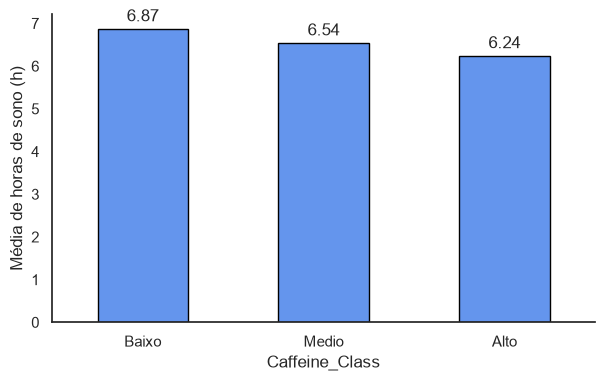

                 count      mean       std  min  25%  50%    75%   max
Caffeine_Class                                                        
Alto            1246.0  6.244382  1.174999  3.0  5.4  6.2  7.075  10.0
Baixo           4021.0  6.871102  1.219471  3.0  6.1  6.9  7.700  10.0
Medio           4733.0  6.539827  1.196865  3.0  5.7  6.5  7.400  10.0


In [27]:
plt.subplots(figsize=(7, 4))

# Verificar a frequência relativa por categoria de Sleep_Quality
ax = tab_cafeina_class.plot(kind="bar",edgecolor="black", color="#6495ED")
ax.set_ylabel("Média de horas de sono (h)")
ax.tick_params(axis='x', labelrotation=0)  
sns.despine(ax=ax)

# Adiciona os valores sobre as barras
for container in ax.containers:
    ax.bar_label(container, fmt="{:.2f}", padding=3)
plt.show()


print(df_features.groupby('Caffeine_Class')['Sleep_Hours'].describe())

Com base nos resultados acima, participantes com alto consumo de cafeína (>= 400 mg/dia) dormem em média 0.63 horas menos do que participantes com baixo consumo (< 200 mg/dia).

A seguir veremos como o Nível de estresse alterar a Qualidade do sono.

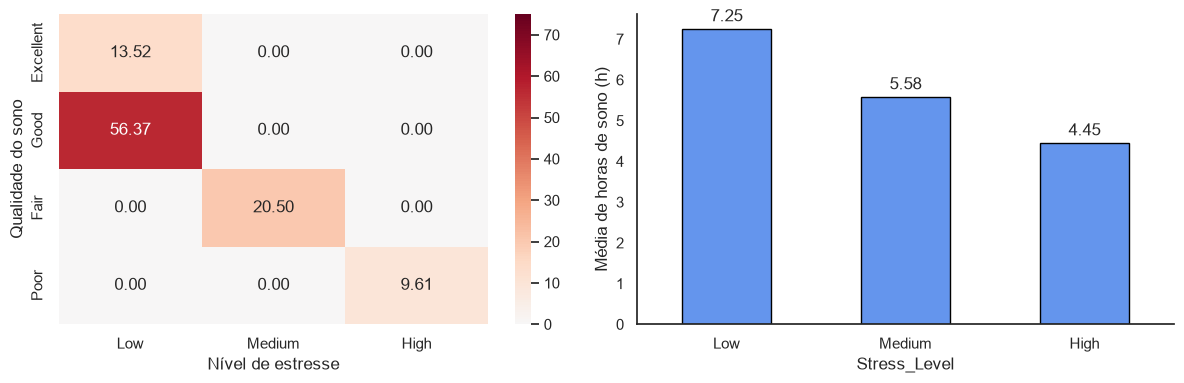

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax = ax.flatten()

# Mapa de calor da distribuição percentual conjunta entre qualidade do sono e nível de estresse
sns.heatmap(tab_sleep_stresse, 
            cmap="RdBu_r", center=0, vmin= 0, vmax=75, annot=True, fmt=".2f", ax=ax[0])
ax[0].set_xlabel('Nível de estresse')
ax[0].set_ylabel('Qualidade do sono')



# Tabela da media da quantidade de horas de sono por nivel de estresse 
tab_sleepHours_stresse = df_features.groupby(['Stress_Level'])['Sleep_Hours'].mean().round(2).reindex(['Low', 'Medium', 'High'])

# Verificar a média de horas de sono por categoria de nível de estresse
tab_sleepHours_stresse.plot(kind="bar",edgecolor="black", color="#6495ED", ax=ax[1])
ax[1].set_ylabel("Média de horas de sono (h)")
ax[1].tick_params(axis='x', labelrotation=0)  
sns.despine(ax=ax[1])

# Adiciona os valores sobre as barras
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="{:.2f}", padding=3)

plt.tight_layout()
plt.show()

Observa-se uma forte associação entre o nível de estresse e a qualidade do sono. Indivíduos com baixo nível de estresse concentram as categorias de Qualidade do sono Excellent e Good, representando, conjuntamente, 69,89% das observações. Já o nível de estresse Medium está associado predominantemente à qualidade Fair (20,50%), enquanto a qualidade Poor concentra-se no grupo de alto estresse (9,61%). Essa relação também é evidenciada pelas médias de horas de sono, que apresentam uma redução progressiva conforme o nível de estresse aumenta: 7,25 horas para Low, 5,58 horas para estresse Medium e 4,45 horas para High. Dessa forma, os resultados indicam uma associação consistente entre maior nível de estresse, menor duração do sono e pior qualidade do sono.

Embora os resultados evidenciem uma associação clara entre estresse e características do sono, esses dados, isoladamente, não permitem estabelecer uma relação de causalidade entre as variáveis.

**2.4 - Principais Descobertas**

- A qualidade do sono tem associação negativa com o nível de estresse;
- A qualidade do sono tem relação positiva com a quantidade de horas de sono;
- O nível de estresse tem relação negativa com a quantidade de horas de sono;
- O nível de estresse tem associação positiva com níveis de cafeína/ consumo de café;
- As distribuições de horas de sono, qualidade do sono e nível de estresse são bastante semelhantes entre os gêneros;
- O nível de estresse tem relação positiva com o consumo médio de café; 
- O consumo de cafeína tem relação negativa com a quantidade de horas de sono;
- Maiores níveis de estresse estão associados a menos horas de sono e a uma pior qualidade do sono.


# Parte 3

## **Modelo preditivo**

O time deseja prever a qualidade do sono (Sleep_Quality) com base nos hábitos e características dos clientes. Nosso último passo será preparar os dados e implementar modelos de classificação.

**3.1. Pré-processamento dos dados:**


Variável alvo (target): **Sleep_Quality**

In [29]:
df_prep = df_features.copy()

**Remover colunas irrelevantes.**

In [30]:
# Remover colunas irrelevantes para a análise
colunas_remover = ['ID', 'Country', 'Sleep_Quality', 'Occupation', 'Caffeine_Class', 'stress_level_numeric']
df_prep.drop(columns=colunas_remover, inplace=True)

# remover coluna Health_Issues (possui elevada quantidade de valores nulos)
df_prep.drop(columns=['Health_Issues'], inplace=True)

# remover coluna Caffeine_mg por colinearidade com Coffee_Intake
df_prep.drop(columns=['Caffeine_mg'], inplace=True)

**Variável derivada:** Como observamos que maiores níveis de estresse estão associados a menos horas de sono, podemos criar uma feature que represente a deficiência de sono em relação a 8 horas.

O valor de 8 horas foi utilizado como referência para a construção da variável de déficit de sono, por estar dentro da faixa de duração de sono geralmente recomendada para adultos e por fornecer um ponto de referência único para comparar os indivíduos da amostra.

In [31]:
df_prep['Sleep_Deficit'] = 8 - df_prep['Sleep_Hours']

Com o intuito de evitar data leakage (vazamento de dados) iremos separar o conjunto de dados antes de aplicar qualquer transformação aos dados e, assim, garantir que o modelo não veja as "informações do futuro" ou do conjunto de teste.

**3.2. Divida os dados em treino e teste.**

In [32]:
from sklearn.model_selection import train_test_split

# Separar X e y
X = df_prep.drop(columns='sleep_quality_numeric')
y = df_prep['sleep_quality_numeric']


# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8000, 11), (8000,), (2000, 11), (2000,))

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline



# Definir grupos de variáveis

## Variáveis categóricas → One-Hot Encoding
colunas_cat = ['Gender','Stress_Level']
## Variáveis numéricas → StandardScaler
colunas_num_escalar = ['Age', 'Coffee_Intake', 'Sleep_Hours', 'BMI', 'Heart_Rate', 
            'Physical_Activity_Hours', 'Sleep_Deficit']


def criar_pipeline(modelo):

    # Criar o preprocessador
    preprocessador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),colunas_cat),  # 3.1.2. Aplicar codificação em variáveis categóricas.
            ('num', StandardScaler(), colunas_num_escalar)
        ],
        verbose_feature_names_out=False,
        remainder='passthrough'
    )

    return Pipeline(
        steps=[('preprocessador', preprocessador), 
               ('modelo', modelo)])

A codificação e padronização dos dados forão aplicadas dentro do Pipeline.

In [34]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Definir validação cruzada estratificada com 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir métricas de avaliação
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

**3.3. Treinar modelos de classificação**

**Logistic Regression**

In [35]:
from sklearn.linear_model import LogisticRegression

# Criar modelo de regressão logística
modelo_lr = criar_pipeline(LogisticRegression(max_iter=1000, random_state=42))

# Realizar validação cruzada com métricas de avaliação
resultado_lr = cross_validate(modelo_lr, X_train, y_train, cv=cv,
        scoring=scoring, return_train_score=True, n_jobs=-1)


In [36]:
# Treinar modelo
modelo_lr.fit(X_train, y_train)

# Fazer previsões
y_pred_lr = modelo_lr.predict(X_test)
y_pred_lr

array([2, 2, 3, ..., 2, 1, 1], shape=(2000,))

**LightGBM**

In [37]:
from lightgbm import LGBMClassifier

# Criar modelo LightGBM
modelo_lgbm = criar_pipeline(LGBMClassifier(random_state=42, verbose=-1))

# Realizar validação cruzada com métricas de avaliação
resultado_lgbm = cross_validate(modelo_lgbm, X_train, y_train, cv=cv,
        scoring=scoring, return_train_score=True, n_jobs=-1)

In [38]:
# Treinar modelo
modelo_lgbm.fit(X_train, y_train)

# Fazer previsões
y_pred_lgbm = modelo_lgbm.predict(X_test)
y_pred_lgbm

array([2, 2, 3, ..., 2, 1, 1], shape=(2000,))

**XGBoost**

In [39]:
from xgboost import XGBClassifier


# Criar modelo XGBClassifier
modelo_xgb = criar_pipeline(XGBClassifier(random_state=42))

# Realizar validação cruzada com métricas de avaliação
resultado_xgb = cross_validate(modelo_xgb, X_train, y_train, cv=cv,
        scoring=scoring, return_train_score=True, n_jobs=-1)

In [40]:
# Treinar modelo
modelo_xgb.fit(X_train, y_train)

# Fazer previsões
y_pred_xgb = modelo_xgb.predict(X_test)
y_pred_xgb

array([2, 2, 3, ..., 2, 1, 1], shape=(2000,))

**Comparar resultados**

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def plotar_matriz_confusao(y_true, y_pred, rotulos, titulo, ax, normalize= None):

    cm = confusion_matrix(y_true, y_pred, normalize= normalize)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rotulos)
    disp.plot(cmap='Blues', values_format='.2f' if normalize else '.0f', ax=ax)
    ax.set_title(titulo)


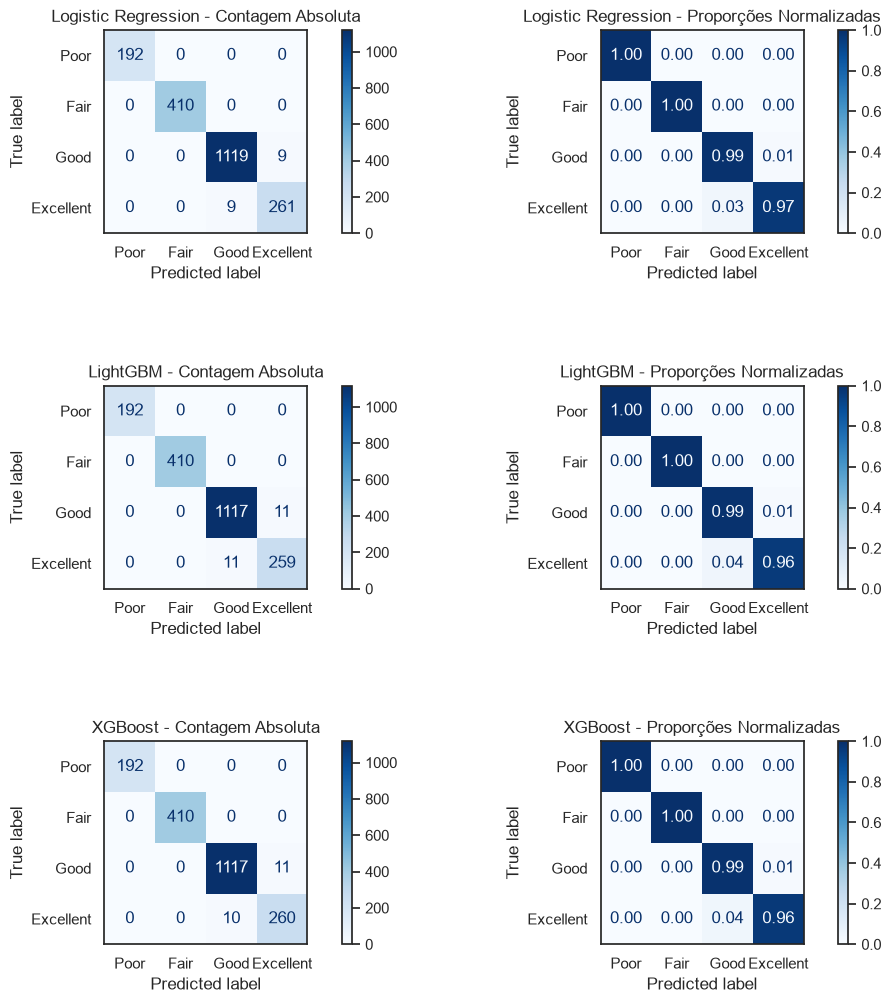

In [42]:
# Plotar as matrizes de confusão para os três modelos
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

rotulos = ['Poor', 'Fair', 'Good', 'Excellent']
plotar_matriz_confusao(y_test, y_pred_lr, rotulos= rotulos, titulo="Logistic Regression - Contagem Absoluta", ax= axes[0], normalize= None)
plotar_matriz_confusao(y_test, y_pred_lr, rotulos= rotulos, titulo="Logistic Regression - Proporções Normalizadas", ax= axes[1], normalize= 'true')

plotar_matriz_confusao(y_test, y_pred_lgbm, rotulos= rotulos, titulo="LightGBM - Contagem Absoluta", ax= axes[2], normalize= None)
plotar_matriz_confusao(y_test, y_pred_lgbm, rotulos= rotulos, titulo="LightGBM - Proporções Normalizadas", ax= axes[3], normalize= 'true')

plotar_matriz_confusao(y_test, y_pred_xgb, rotulos= rotulos, titulo="XGBoost - Contagem Absoluta", ax= axes[4], normalize= None)
plotar_matriz_confusao(y_test, y_pred_xgb, rotulos= rotulos, titulo="XGBoost - Proporções Normalizadas", ax= axes[5], normalize= 'true')


plt.tight_layout(pad=0.5, h_pad=5, w_pad= -10)
plt.show()

In [43]:
print('=======  Resultados da Validação Cruzada no Treino (Logistic Regression)  ======= \n')
print('Precision (Treino):', resultado_lr['train_precision_macro'], '-> Média:', resultado_lr['train_precision_macro'].mean().round(4))
print('Recall (Treino):', resultado_lr['train_recall_macro'], '-> Média:', resultado_lr['train_recall_macro'].mean().round(4))
print('F1 (Treino):', resultado_lr['train_f1_macro'], '-> Média:', resultado_lr['train_f1_macro'].mean().round(4))
print('Accuracy (Treino):', resultado_lr['train_accuracy'], '-> Média:', resultado_lr['train_accuracy'].mean().round(4))


print('\n=======  classification report Logistic Regression  ======= ') 
print(classification_report(y_test, y_pred_lr, labels = [0, 1, 2, 3], target_names=rotulos, zero_division=0), '\n')


=======  Resultados da Validação Cruzada no Treino (Logistic Regression)  ======= 

Precision (Treino): [0.99308865 0.99366574 0.99276455 0.99403219 0.99352506] -> Média: 0.9934
Recall (Treino): [0.99072925 0.98979179 0.99255145 0.99123521 0.9913769 ] -> Média: 0.9911
F1 (Treino): [0.9918984  0.99170039 0.99265792 0.99261894 0.99244226] -> Média: 0.9923
Accuracy (Treino): [0.99296875 0.9928125  0.99359375 0.99359375 0.9934375 ] -> Média: 0.9933

=======  classification report Logistic Regression  ======= 
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.99      0.99      0.99      1128
   Excellent       0.97      0.97      0.97       270

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000
 



In [44]:
print('=======  Resultados da Validação Cruzada no Treino (LightGBM)  ======= \n')
print('Precision (Treino):', resultado_lgbm['train_precision_macro'], '-> Média:', resultado_lgbm['train_precision_macro'].mean().round(4))
print('Recall (Treino):', resultado_lgbm['train_recall_macro'], '-> Média:', resultado_lgbm['train_recall_macro'].mean().round(4))
print('F1 (Treino):', resultado_lgbm['train_f1_macro'], '-> Média:', resultado_lgbm['train_f1_macro'].mean().round(4))
print('Accuracy (Treino):', resultado_lgbm['train_accuracy'], '-> Média:', resultado_lgbm['train_accuracy'].mean().round(4))

print('\n=======  classification report LightGBM  =======') 
print(classification_report(y_test, y_pred_lgbm, labels = [0, 1, 2, 3], target_names=rotulos, zero_division=0), '\n')

=======  Resultados da Validação Cruzada no Treino (LightGBM)  ======= 

Precision (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
Recall (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
F1 (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
Accuracy (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0

=======  classification report LightGBM  =======
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.99      0.99      0.99      1128
   Excellent       0.96      0.96      0.96       270

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000
 



In [45]:
print('=======  Resultados da Validação Cruzada no Treino (XGBoost)  ======= \n')
print('Precision (Treino):', resultado_xgb['train_precision_macro'], '-> Média:', resultado_xgb['train_precision_macro'].mean().round(4))
print('Recall (Treino):', resultado_xgb['train_recall_macro'], '-> Média:', resultado_xgb['train_recall_macro'].mean().round(4))
print('F1 (Treino):', resultado_xgb['train_f1_macro'], '-> Média:', resultado_xgb['train_f1_macro'].mean().round(4))
print('Accuracy (Treino):', resultado_xgb['train_accuracy'], '-> Média:', resultado_xgb['train_accuracy'].mean().round(4))

print('\n=======  classification report XGBoost  =======') 
print(classification_report(y_test, y_pred_xgb, labels = [0, 1, 2, 3], target_names=rotulos, zero_division=0))

=======  Resultados da Validação Cruzada no Treino (XGBoost)  ======= 

Precision (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
Recall (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
F1 (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0
Accuracy (Treino): [1. 1. 1. 1. 1.] -> Média: 1.0

=======  classification report XGBoost  =======
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.99      0.99      0.99      1128
   Excellent       0.96      0.96      0.96       270

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



**3.4. Documente a avaliação:**

A Regressão Logística apresentou o melhor equilíbrio entre desempenho e capacidade de generalização. O modelo apresentou F1-macro médio de 0,9923 na validação cruzada e desempenho aproximadamente equivalente no conjunto de teste, indicando baixa variabilidade entre treinamento e dados não utilizados no ajuste.

LightGBM e XGBoost apresentaram desempenho perfeito durante a validação cruzada (F1 = 1,00), 1porém apresentaram pequena redução no conjunto de teste, especialmente na classe Excellent (F1 = 0,96). Esse comportamento sugere possível overfitting, embora a capacidade de generalização permaneça elevada.

**3.5. Salvar o datasets processados em CSV**

In [46]:
# Recuperar o preprocessador já ajustado pelo Pipeline
preprocessador_ajustado = modelo_lr.named_steps['preprocessador']

# Recuperar os nomes das variáveis após o preprocessamento
colunas_transformadas = preprocessador_ajustado.get_feature_names_out()
print(colunas_transformadas)

['Gender_Female' 'Gender_Male' 'Gender_Other' 'Stress_Level_High'
 'Stress_Level_Low' 'Stress_Level_Medium' 'Age' 'Coffee_Intake'
 'Sleep_Hours' 'BMI' 'Heart_Rate' 'Physical_Activity_Hours'
 'Sleep_Deficit' 'Smoking' 'Alcohol_Consumption']


In [47]:
# Transformar os dados usando o preprocessador ajustado
X_train_transformado = preprocessador_ajustado.transform(X_train)
X_test_transformado = preprocessador_ajustado.transform(X_test)


# Criar DataFrames
X_train_transformado = pd.DataFrame(X_train_transformado, 
                                    columns=colunas_transformadas,    
                                    index=X_train.index)

X_test_transformado = pd.DataFrame(X_test_transformado,    
                                   columns=colunas_transformadas,     
                                   index=X_test.index)


In [48]:
# Concatenar X_train_transformado e y_train em um único DataFrame
df_train_transformado = pd.concat([X_train_transformado, y_train], axis=1)

# Concatenar X_test_transformado e y_test em um único DataFrame
df_test_transformado = pd.concat([X_test_transformado, y_test], axis=1)

display(df_train_transformado.head())
display(df_test_transformado.head())

,Gender_Female,Gender_Male,Gender_Other,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium,Age,Coffee_Intake,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Sleep_Deficit,Smoking,Alcohol_Consumption,sleep_quality_numeric
4421,1.0,0.0,0.0,0.0,0.0,1.0,-1.261143,-0.356827,-1.095484,-1.115580,-1.094984,-1.176046,1.095484,1.0,0.0,1
9389,1.0,0.0,0.0,0.0,1.0,0.0,0.801545,0.746566,0.871899,0.213728,-0.074496,-1.014387,-0.871899,1.0,1.0,2
7418,0.0,1.0,0.0,0.0,1.0,0.0,-0.095276,0.332794,-0.357715,1.312963,1.150091,0.209599,0.357715,0.0,1.0,2
5224,1.0,0.0,0.0,0.0,1.0,0.0,3.133278,-0.770599,1.691643,-0.911071,-0.380642,0.348164,-1.691643,1.0,0.0,3
4033,0.0,1.0,0.0,0.0,1.0,0.0,-1.530189,-0.012017,0.953874,-1.856925,1.252140,-1.430081,-0.953874,0.0,1.0,2


,Gender_Female,Gender_Male,Gender_Other,Stress_Level_High,Stress_Level_Low,Stress_Level_Medium,Age,Coffee_Intake,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Sleep_Deficit,Smoking,Alcohol_Consumption,sleep_quality_numeric
6745,0.0,1.0,0.0,0.0,1.0,0.0,-1.081778,0.539680,0.789925,-0.195290,-0.686789,-0.460129,-0.789925,1.0,0.0,2
5857,1.0,0.0,0.0,0.0,1.0,0.0,-0.633368,2.608541,0.789925,2.054308,-0.788838,0.763857,-0.789925,1.0,0.0,2
3986,1.0,0.0,0.0,0.0,1.0,0.0,0.532498,-0.287865,1.199797,0.367109,-0.482691,-0.483224,-1.199797,0.0,0.0,3
7457,0.0,1.0,0.0,0.0,1.0,0.0,0.801545,0.608642,0.298079,1.389654,0.945993,-0.714164,-0.298079,0.0,0.0,2
2165,0.0,1.0,0.0,0.0,1.0,0.0,-1.171461,0.401756,-0.193767,-1.320089,0.027553,1.040986,0.193767,0.0,0.0,2


In [49]:
# Salvar os DataFrames transformados em arquivos CSV
df_train_transformado.to_csv('df_train_transformado.csv', index=False)
df_test_transformado.to_csv('df_test_transformado.csv', index=False)

**3.6. Salvar o melhor modelo**

In [50]:
# Salvar modelo de regressão logística ajustado em um arquivo pickle
import pickle
with open('modelo_lr.pkl', 'wb') as f:
    pickle.dump(modelo_lr, f)

**3.7. Recomendações para o Negócio**

A partir dos resultados obtidos nas etapas de análise exploratória, visualização e modelagem preditiva, é possível traduzir os achados em ações concretas para a empresa orientar seus clientes sobre hábitos de café e sono. O primeiro ponto de atenção é o consumo de cafeína: clientes com ingestão elevada (acima de 400 mg/dia, cerca de 4 xícaras) dormem, em média, 0,63 hora a menos do que aqueles com baixo consumo. Isso justifica a criação de alertas personalizados em aplicativos ou plataformas da empresa, sugerindo de forma proativa a redução gradual da cafeína, especialmente no período da tarde, como uma intervenção simples e de baixo custo.

Mais importante ainda, os dados mostram que o nível de estresse é o fator mais fortemente associado à qualidade e à quantidade de sono, com correlações muito mais fortes do que as observadas para o café isoladamente. Pessoas com baixo estresse dormem, em média, 7,25 horas, enquanto aquelas com estresse alto dormem apenas 4,45 horas. Isso significa que a empresa deveria priorizar programas de gestão de estresse — como mindfulness, respiração guiada ou parcerias com apps de bem-estar — como parte central de sua proposta de valor, comunicando claramente ao cliente que reduzir o estresse tende a gerar ganhos maiores no sono do que apenas cortar o café.

Também vale destacar que o consumo de café tende a ser maior justamente entre pessoas mais estressadas, sugerindo que muitos clientes usam a cafeína como estratégia paliativa para compensar o cansaço causado pelo próprio estresse ou sono ruim, criando um possível ciclo de retroalimentação (estresse → sono ruim → mais café → sono ainda pior). Ao identificar esse padrão, sobretudo entre clientes de 18 a 69 anos — faixa etária em que a relação é mais evidente —, a empresa pode direcionar conteúdo educativo específico para ajudar o cliente a romper esse ciclo, além de segmentar campanhas de conscientização por faixa etária para maximizar o impacto.

Por fim, o modelo preditivo desenvolvido (Regressão Logística, com F1-macro de aproximadamente 0,99 e boa capacidade de generalização) pode ser incorporado a um painel interno ou ao próprio aplicativo do cliente como um "score de risco de sono ruim", permitindo que a empresa identifique proativamente pessoas propensas a ter sono de qualidade ruim e ofereça intervenções antes que o problema se agrave. Ao comunicar essas descobertas, no entanto, é importante deixar claro que se trata de relações correlacionais, não causais, reforçando a recomendação de acompanhamento profissional em casos específicos — o que preserva a credibilidade da marca. Em síntese, a estratégia mais eficaz combina monitoramento do consumo de cafeína, foco em gestão de estresse, segmentação por perfil etário e uso de modelos preditivos para personalizar recomendações, agregando valor mensurável ao serviço oferecido pela empresa.